In [40]:
import numpy as np
import cv2
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline 

In [41]:
img=cv2.imread('./test_images/che.jpeg')
img.shape

(255, 198, 3)

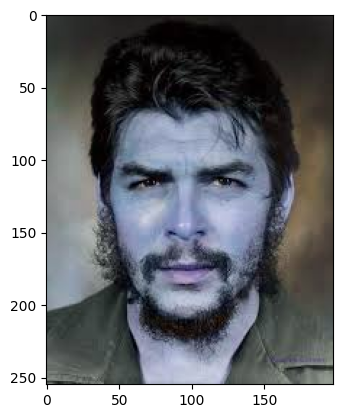

In [42]:
plt.imshow(img)

Face detected!


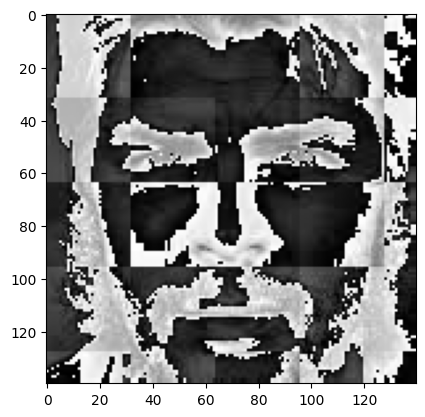

In [71]:
# 1. Load and convert to grayscale (Haar works best on gray)
img = cv2.imread('./test_images/che.jpeg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. Use more sensitive parameters
# scaleFactor=1.1: smaller steps make it more thorough
# minNeighbors=3: lower value makes it easier to detect faces
faces = face_cascade.detectMultiScale(gray, 1.1, 3)

# 3. Only attempt to crop if a face was actually found
if len(faces) > 0:
    (x, y, w, h) = faces[0]
    cropped_img = img[y:y+h, x:x+w]
    print("Face detected!")
    
    # Now you can safely run your wavelet function
    im_har = w2d(cropped_img, 'db1', 5)
    plt.imshow(im_har, cmap='gray')
    plt.show()
else:
    print("No face detected with current settings. Try lowering minNeighbors further.")

In [72]:
(x,y,w,h) = faces[0]
x,y,w,h

(np.int32(27), np.int32(62), np.int32(139), np.int32(139))

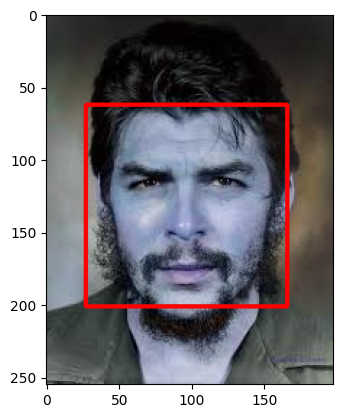

In [73]:
face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
plt.imshow(face_img)

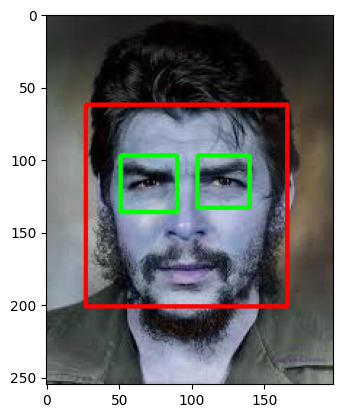

In [74]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
cv2.destroyAllWindows()
for (x,y,w,h) in faces:
    face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = face_img[y:y+h, x:x+w]
    eyes = eye_cascade.detectMultiScale(roi_gray)
    for (ex,ey,ew,eh) in eyes:
        cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,255,0),2)
        

plt.figure()
plt.imshow(face_img, cmap='gray')
plt.show()

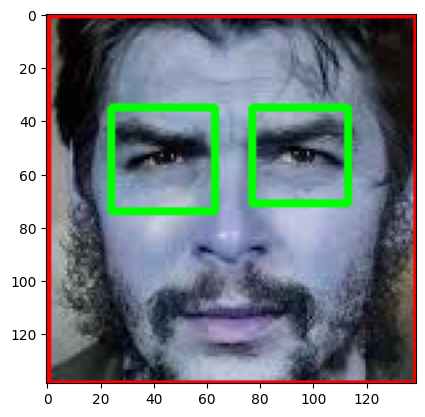

In [75]:
%matplotlib inline
plt.imshow(roi_color, cmap='gray')

In [76]:
def get_cropped_image_if_2_eyes(image_path):
    img = cv2.imread(image_path)
    
    if img is None:
        print(f"Skipping invalid file: {image_path}")
        return None
        
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 4)
    
    for (x, y, w, h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray, 1.1, 2)
        
        if len(eyes) >= 2:
            return roi_color
            
    return None

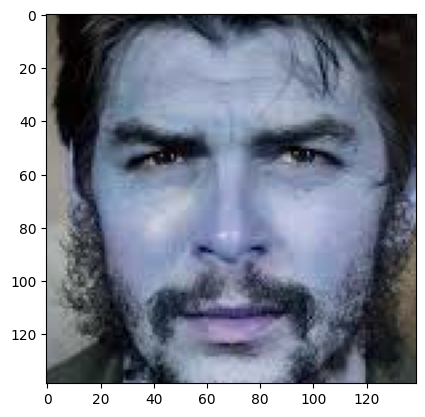

In [77]:
cropped_image = get_cropped_image_if_2_eyes('./test_images/che.jpeg')
plt.imshow(cropped_image)

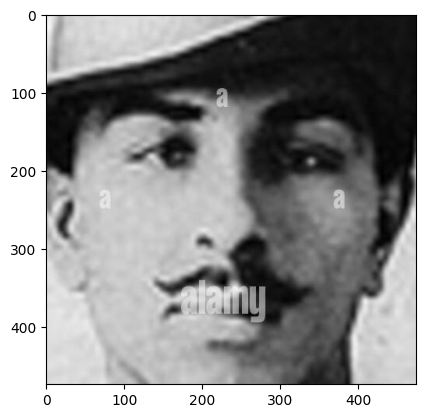

In [78]:
cropped_image = get_cropped_image_if_2_eyes('./test_images/bhagat.jpg')
plt.imshow(cropped_image)

In [79]:
path_to_data = "./model/dataset/"
path_to_cr_data = "./model/dataset/cropped/"

In [80]:
import os
img_dirs = []
for entry in os.scandir(path_to_data):
    if entry.is_dir():
        img_dirs.append(entry.path)
img_dirs

['./model/dataset/FIDEL CASTRO',
 './model/dataset/XI JINPING',
 './model/dataset/BHAGAT',
 './model/dataset/CHE GUEVARA',
 './model/dataset/.ipynb_checkpoints',
 './model/dataset/cropped',
 './model/dataset/LENIN']

In [81]:
import shutil
if os.path.exists(path_to_cr_data):
     shutil.rmtree(path_to_cr_data)
os.mkdir(path_to_cr_data)

In [82]:
cropped_image_dirs = []
file_names_dict = {}

for img_dir in img_dirs:
    count = 1
    name = img_dir.split('/')[-1]
    print(name)
    
    file_names_dict[name] = []
    
    for entry in os.scandir(img_dir):
        roi_color = get_cropped_image_if_2_eyes(entry.path)
        if roi_color is not None:
            cropped_folder = path_to_cr_data +name
            if not os.path.exists(cropped_folder):
                os.makedirs(cropped_folder)
                cropped_image_dirs.append(cropped_folder)
                print("Generating cropped images in folder: ",cropped_folder)
                
            cropped_file_name = name + str(count) + ".png"
            cropped_file_path = cropped_folder + "/" + cropped_file_name 
            
            cv2.imwrite(cropped_file_path, roi_color)
            file_names_dict[name].append(cropped_file_path)
            count += 1    

FIDEL CASTRO
Generating cropped images in folder:  ./model/dataset/cropped/FIDEL CASTRO
XI JINPING
Generating cropped images in folder:  ./model/dataset/cropped/XI JINPING
BHAGAT
Generating cropped images in folder:  ./model/dataset/cropped/BHAGAT
Skipping invalid file: ./model/dataset/BHAGAT/.DS_Store
CHE GUEVARA
Generating cropped images in folder:  ./model/dataset/cropped/CHE GUEVARA
.ipynb_checkpoints
cropped
Skipping invalid file: ./model/dataset/cropped/FIDEL CASTRO
Skipping invalid file: ./model/dataset/cropped/XI JINPING
Skipping invalid file: ./model/dataset/cropped/BHAGAT
Skipping invalid file: ./model/dataset/cropped/CHE GUEVARA
LENIN
Generating cropped images in folder:  ./model/dataset/cropped/LENIN


In [83]:
cropped_img = np.array(roi_color)
cropped_img.shape

()

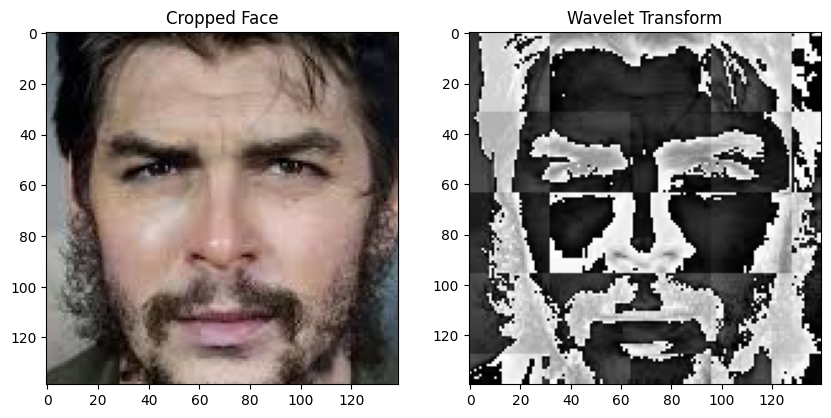

In [90]:
import numpy as np
import pywt
import cv2
import matplotlib.pyplot as plt

# 1. Define the Wavelet Transform Function
def w2d(img, mode='haar', level=1):
    # Ensure input is a valid numpy array
    imArray = np.array(img)
    # Convert to grayscale
    imArray = cv2.cvtColor(imArray, cv2.COLOR_RGB2GRAY)
    # Convert to float and normalize
    imArray = np.float32(imArray)   
    imArray /= 255
    # Compute coefficients
    coeffs = pywt.wavedec2(imArray, mode, level=level)

    # Process Coefficients: Zero out the approximation (low-frequency)
    coeffs_H = list(coeffs)  
    coeffs_H[0] *= 0  

    # Reconstruction
    imArray_H = pywt.waverec2(coeffs_H, mode)
    imArray_H *= 255
    imArray_H = np.uint8(imArray_H)

    return imArray_H

# 2. Setup Cascades
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# 3. Load Image and Detect
img = cv2.imread('./test_images/che.jpeg')

if img is None:
    print("Error: Image not found. Check your file path.")
else:
    # Convert to gray for the detector (CRITICAL STEP)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Detect faces with sensitive parameters (1.1 and 3)
    faces = face_cascade.detectMultiScale(gray, 1.1, 3)

    if len(faces) > 0:
        # Crop the first face found
        (x, y, w, h) = faces[0]
        cropped_img = img[y:y+h, x:x+w]
        
        # 4. Run Wavelet Transform
        im_har = w2d(cropped_img, 'db1', 5)
        
        # 5. Display Result
        plt.figure(figsize=(10,5))
        plt.subplot(1,2,1)
        plt.imshow(cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB))
        plt.title("Cropped Face")
        
        plt.subplot(1,2,2)
        plt.imshow(im_har, cmap='gray')
        plt.title("Wavelet Transform")
        plt.show()
    else:
        print("Face detection failed. The photo might be too dark or tilted.")

In [101]:
def get_cropped_image_if_2_eyes(image_path):
    img = cv2.imread(image_path)
    
    # 1. Check if image was successfully loaded
    if img is None:
        return None
        
    # 2. Proceed with conversion and detection
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    
    for (x,y,w,h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]
        
        # Look for eyes specifically within the face area (ROI)
        eyes = eye_cascade.detectMultiScale(roi_gray)
        if len(eyes) >= 2:
            return roi_color
            
    return None # Return None if no face with 2 eyes is found

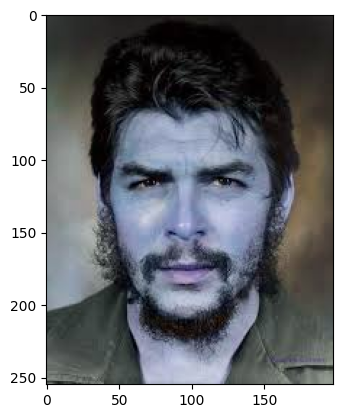

In [102]:
original_image = cv2.imread('./test_images/che.jpeg')
plt.imshow(original_image)

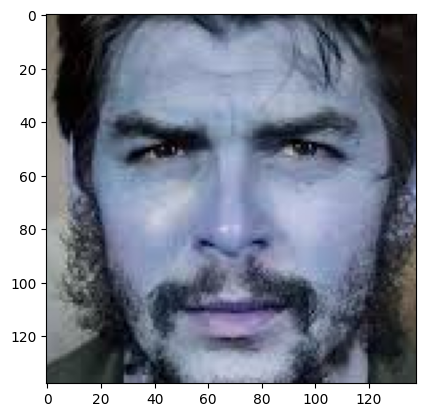

In [103]:
cropped_image = get_cropped_image_if_2_eyes('./test_images/che.jpeg')
plt.imshow(cropped_image)

In [104]:
image_dirs = []
file_names_dict = {}
for img_dir in img_dirs:
    count = 1
    name = img_dir.split('/')[-1]
    file_names_dict[name] = []
    for entry in os.scandir(img_dir):
        roi_color = get_cropped_image_if_2_eyes(entry.path)
        if roi_color is not None:
            cropped_folder = path_to_cr_data + name
            if not os.path.exists(cropped_folder):
                os.makedirs(cropped_folder)
                cropped_image_dirs.append(cropped_folder)
                print("Generating cropped images in folder: ",cropped_folder)
            cropped_file_name = name + str(count) + ".png"
            cropped_file_path = cropped_folder + "/" + cropped_file_name
            cv2.imwrite(cropped_file_path, roi_color)
            file_names_dict[name].append(cropped_file_path)
            count += 1

In [105]:
file_names_dict = {}
for img_dir in image_dirs:
    name = img_dir.split('/')[-1]
    file_list = []
    for entry in os.scandir(img_dir):
        file_list.append(entry.path)
    file_names_dict[name] = file_list
file_names_dict

{}